In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from model import MazeTransformer
import torch
import yaml

MODEL_NAME = "replicate_smart_boi"
STATE_DICT_PATH = f'./models/{MODEL_NAME}/model'
with open(f"./models/{MODEL_NAME}/config.yaml", "r") as f:
    config = yaml.safe_load(f)

model = MazeTransformer(config["model"])
model.load_state_dict(torch.load(STATE_DICT_PATH, weights_only=True))
model.eval()

MazeTransformer(
  (embedding_layer): Embedding(10, 256)
  (pos_embedding_layer): Embedding(128, 256)
  (transformer_blocks): ModuleList(
    (0-9): 10 x TransformerBlock(
      (attn): MultiHeadAttention(
        (qkv): Linear(in_features=256, out_features=768, bias=True)
        (out_proj): Linear(in_features=256, out_features=256, bias=True)
      )
      (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=256, out_features=1024, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=1024, out_features=256, bias=True)
        (3): Dropout(p=0, inplace=False)
      )
    )
  )
  (ln): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=256, out_features=5, bias=True)
)

In [3]:
from supervised import MazeDataset, create_causal_mask
from generate_dataset import generate_dataset
import os

config["dataset"]["output_dir"] = "inference_data"
generate_dataset(config["dataset"])
train_dataset = MazeDataset(os.path.join("./inference_data", "train"))

Generating data for eight


100%|██████████| 1024/1024 [00:00<00:00, 3430.17it/s]


In [4]:
sequences, targets, sizes, _ = train_dataset[100]

sequences = sequences.unsqueeze(0)
targets = targets.unsqueeze(0)
sizes = sizes.unsqueeze(0)

seq_len = sequences.shape[1]
masks = create_causal_mask(sizes, seq_len)

sequences = sequences.to(config["model"]["device"])
masks = masks.to(config["model"]["device"])

model_out = model.forward(sequences, masks).squeeze()

sz = sizes.item()
predictions = model_out.squeeze()[sz - 1: sz - 1 + targets[0].shape[0]]

In [5]:
print("Predicted:", torch.argmax(predictions, dim=-1))
print("Target:   ", targets.squeeze())

Predicted: tensor([3, 3, 3, 0, 0, 0, 3, 3, 3, 0, 0, 3, 0, 0, 4], device='cuda:0')
Target:    tensor([3, 3, 3, 0, 0, 0, 3, 3, 3, 0, 0, 3, 0, 0, 4])


In [6]:
ex_in = sequences[0][:sizes[0]].to('cuda')
print(ex_in)
generated_path = model.generate(ex_in, method="")
print(generated_path)
print(targets.squeeze())
print((generated_path == targets[0].to('cuda')).all())

tensor([6, 5, 6, 5, 5, 6, 6, 6, 7, 6, 5, 6, 6, 6, 6, 5, 6, 7, 6, 5, 5, 5, 6, 5,
        6, 6, 7, 6, 6, 6, 6, 5, 6, 6, 5, 7, 5, 5, 5, 6, 6, 5, 6, 6, 7, 6, 6, 5,
        6, 5, 6, 6, 5, 7, 6, 5, 6, 6, 6, 6, 5, 6, 7, 6, 6, 6, 5, 5, 6, 6, 6, 7,
        8], device='cuda:0')
tensor([3, 3, 3, 0, 0, 0, 3, 3, 3, 0, 0, 3, 0, 0, 4], device='cuda:0')
tensor([3, 3, 3, 0, 0, 0, 3, 3, 3, 0, 0, 3, 0, 0, 4])
tensor(True, device='cuda:0')


In [7]:
from torch.utils.data import DataLoader

from supervised import maze_collate_fn

ex_dataloader = DataLoader(train_dataset, batch_size=5, collate_fn=maze_collate_fn)
for batch in ex_dataloader:
    ex_batch = batch
    break

In [8]:
sequences, targets, sizes, dataset_names = ex_batch
sequences.shape # (batch_size, padded_seq_len)

torch.Size([5, 100])

In [9]:
from training_utils import remove_solution_from_sequences

input_sequences = remove_solution_from_sequences(sequences, sizes)

In [24]:
predictions, all_logits = model.generate_rollouts(input_sequences.to(model.device), sizes.to(model.device))

In [26]:
predictions[0]

[3,
 0,
 0,
 0,
 0,
 2,
 0,
 0,
 0,
 3,
 3,
 3,
 1,
 1,
 1,
 1,
 1,
 3,
 3,
 0,
 0,
 3,
 0,
 0,
 0,
 3,
 4]

In [25]:
all_logits[0]

tensor([[-3.7770, -4.8717, -2.7955, 10.4784, -3.3692],
        [11.0364, -2.7765, -3.1470, -3.8994, -2.4687],
        [11.2033, -2.4663, -3.4133, -3.6781, -2.9907],
        [10.7140, -0.9806, -2.1407, -5.2684, -2.5669],
        [10.6287, -1.8970, -1.1616, -5.5790, -2.2059],
        [-1.4850, -7.2476, 10.8875, -1.2110, -2.2644],
        [11.1933, -3.0644, -3.6810, -2.7679, -3.0507],
        [10.6322, -0.7375, -2.6060, -5.1571, -2.6716],
        [11.2523, -3.2218, -4.2623, -1.9961, -3.0231],
        [-3.7107, -5.1657, -2.8801, 10.4936, -3.0322],
        [-2.5398, -5.6269, -3.2292, 10.6738, -3.6800],
        [-5.2242, -1.4367, -2.9727,  9.9591, -3.5448],
        [-3.1410, 12.9290, -2.4179, -3.7101,  0.0431],
        [-4.7980, 11.7164, -1.5426, -1.8166, -2.1760],
        [-5.1041,  9.7376,  0.1439, -1.5828, -1.5031],
        [-0.1797, 11.3308, -3.8709, -4.0705, -0.5820],
        [-3.6441, 11.2490, -4.9100,  0.2878, -1.1931],
        [-5.3814,  2.8284, -4.6159,  7.9904, -3.3516],
        [-

### Generating a big maze

In [10]:
from maze import generate_maze, solve_maze, convert_to_directions
from tokenizer import tokenize

MAZE_SIZE = 16
maze = generate_maze(MAZE_SIZE)
path = convert_to_directions(solve_maze(maze))

tokenized, maze_size = tokenize(maze, path)
maze_tokens = torch.tensor(tokenized[:maze_size]).to("cuda")

print(maze_tokens)

tensor([6, 5, 6, 6, 6, 6, 5, 6, 6, 6, 5, 5, 6, 5, 6, 6, 7, 6, 6, 6, 5, 5, 6, 5,
        6, 5, 6, 6, 6, 6, 6, 6, 5, 7, 5, 5, 5, 6, 5, 6, 6, 5, 6, 5, 6, 5, 5, 5,
        6, 6, 7, 6, 6, 5, 6, 5, 5, 6, 6, 6, 6, 6, 5, 6, 5, 6, 5, 7, 5, 6, 6, 6,
        6, 6, 5, 5, 5, 5, 6, 5, 6, 5, 6, 6, 7, 6, 6, 5, 6, 5, 6, 5, 6, 6, 6, 5,
        6, 6, 5, 5, 6, 7, 6, 5, 6, 5, 6, 6, 6, 6, 5, 6, 6, 6, 5, 6, 6, 6, 7, 6,
        5, 6, 6, 5, 5, 6, 5, 6, 5, 6, 5, 6, 6, 5, 6, 7, 6, 6, 5, 6, 6, 6, 5, 6,
        6, 5, 6, 6, 6, 5, 6, 5, 7, 5, 6, 6, 5, 6, 5, 6, 6, 5, 6, 6, 5, 5, 6, 6,
        6, 7, 6, 5, 6, 5, 6, 6, 6, 5, 6, 5, 6, 5, 6, 5, 5, 6, 7, 6, 6, 6, 5, 5,
        6, 5, 6, 6, 6, 5, 6, 6, 6, 6, 6, 7, 6, 5, 5, 6, 6, 6, 5, 6, 5, 6, 6, 6,
        5, 5, 5, 6, 7, 6, 6, 5, 6, 5, 6, 6, 5, 5, 5, 6, 5, 6, 6, 6, 6, 7, 5, 6,
        5, 6, 6, 5, 6, 6, 5, 5, 6, 5, 6, 5, 5, 5, 7, 6, 6, 6, 6, 5, 5, 5, 6, 6,
        6, 6, 5, 6, 6, 6, 6, 7, 8], device='cuda:0')


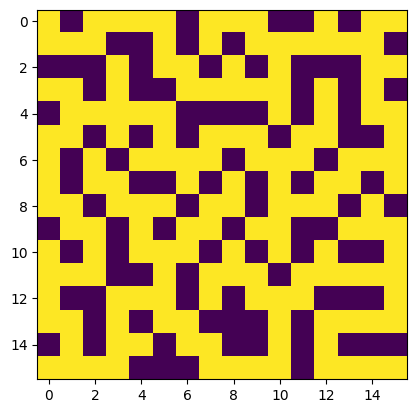

In [11]:
import matplotlib.pyplot as plt

maze_arr = maze_tokens.cpu().numpy()[:-1].reshape((MAZE_SIZE, MAZE_SIZE + 1))[:, :-1]
plt.imshow(maze_arr)

In [9]:
d = {
    0 : "right",
    1 : "left",
    2 : "up",
    3 : "down",
    4 : "eos"
}

model_out = model.generate(maze_tokens).cpu().numpy()
directions = [d[item] for item in model_out]
print(directions)

['right', 'down', 'down', 'down', 'left', 'down', 'down', 'right', 'right', 'down', 'right', 'down', 'right', 'right', 'right', 'right', 'eos']


In [90]:
model.generate(maze_tokens)

tensor([0, 0, 3, 0, 0, 2, 0, 0, 3, 3, 3, 0, 3, 3, 3, 3, 4], device='cuda:0')